In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

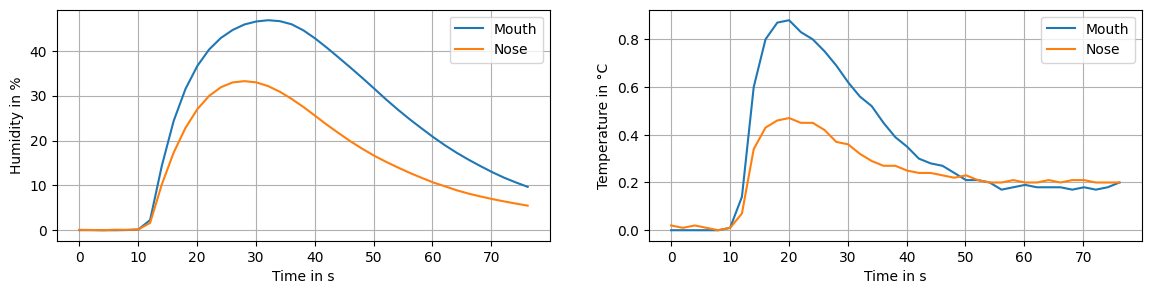

In [4]:
def get_cir(region):
    # load data
    data_all = []
    for i in range(1, 11):
        data = np.loadtxt(f'{os.path.abspath(os.path.join(os.getcwd(), os.pardir))}/data/cir/{region}_trial_{i}.dat', delimiter=',', skiprows=1)
        data_all.append(data)

    # mean over trials
    cir_mean = np.mean(data_all, axis=0)

    # baseline correction
    baseline_humidity = np.min(cir_mean[:, 1])
    baseline_temperature = np.min(cir_mean[:, 2])
    cir_mean[:, 1] -= baseline_humidity
    cir_mean[:, 2] -= baseline_temperature

    return cir_mean[:, 0]/1000, cir_mean[:, 1], cir_mean[:, 2]

# get cir
t, cir_mouth_humidity, cir_mouth_temperature = get_cir('mouth')
t, cir_nose_humidity, cir_nose_temperature = get_cir('nose')

# normalize cir for later
cir_mouth_humidity_norm = cir_mouth_humidity / np.max(cir_mouth_humidity)
cir_mouth_temperature_norm = cir_mouth_temperature / np.max(cir_mouth_temperature)
cir_nose_humidity_norm = cir_nose_humidity / np.max(cir_nose_humidity)
cir_nose_temperature_norm = cir_nose_temperature / np.max(cir_nose_temperature)

# plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 3))
ax[0].plot(t, cir_mouth_humidity, label='Mouth')
ax[0].plot(t, cir_nose_humidity, label='Nose')
ax[0].set_xlabel('Time in s')
ax[0].set_ylabel('Humidity in %')
ax[0].grid()
ax[0].legend()

ax[1].plot(t, cir_mouth_temperature, label='Mouth')
ax[1].plot(t, cir_nose_temperature, label='Nose')
ax[1].set_xlabel('Time in s')
ax[1].set_ylabel('Temperature in °C')
ax[1].grid()
ax[1].legend()
plt.show()

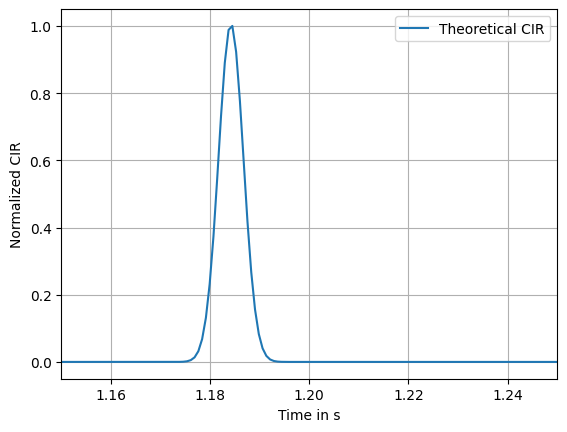

In [17]:
def theoretical_cir(t, M, D, d, v):
    return M / np.sqrt(4 * np.pi * D * t) * np.exp(-(v * t - d)**2 / (4 * D * t))

# params used from Tab. I in "Channel and Noise Models for Nonlinear Molecular  Communication Systems"
D = 0.0959          # Diffusion coefficient [cm^2/s]
d = 225             # Distance Tx-Rx [cm]
v = 190             # velocity towards sensor [cm/s]
M = 1               # Molecules emitted

# upsample time vector
t_upsampled = np.linspace(t.min(), t.max(), 100000)

# theoretical cir
cir_theoretical = theoretical_cir(t_upsampled, M, D, d, v)
cir_theoretical_norm = cir_theoretical / np.max(cir_theoretical)

# plotting
plt.figure()
plt.plot(t_upsampled, cir_theoretical_norm, label='Theoretical CIR')
plt.xlabel('Time in s')
plt.ylabel('Normalized CIR')
plt.grid()
plt.xlim(1.15, 1.25)
plt.legend()
plt.show()

Fitted parameters: [2.68561175e+00 5.61000350e+00 9.75847932e-05 2.15311203e+01
 6.94298975e+02]


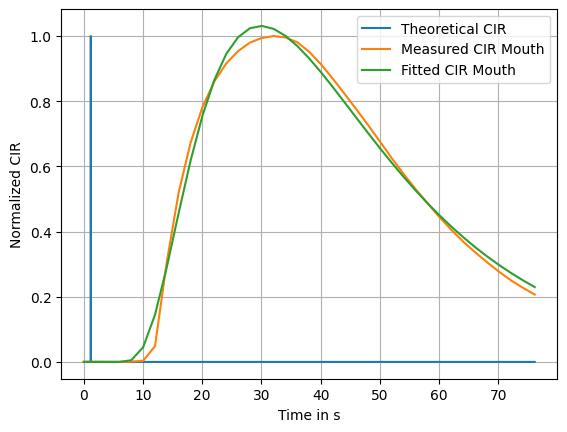

In [ ]:
def fit_cir(t, t0, a, b, c, d):
    tp = np.maximum(t - t0, 1e-6)
    return a / np.sqrt(tp) * np.exp(-b * (d - c * tp)**2 / tp)

peak_idx = np.argmax(cir_mouth_humidity_norm)
t0 = t[peak_idx]
a0 = cir_mouth_humidity_norm[peak_idx]*np.sqrt(t[peak_idx])
initial_guess = [t0, a0, 1e-4, 54, 190]
lower_bound, upper_bound = [0, 0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf, np.inf]

popt, pcov = curve_fit(fit_cir, t, cir_mouth_humidity_norm, p0=initial_guess, bounds=(lower_bound, upper_bound))
print(f"Fitted parameters: a={popt[1]}, b={popt[2]}, c={popt[3]}, d={popt[4]}")

plt.figure()
plt.plot(t_upsampled, cir_theoretical_norm, label='Theoretical CIR')
plt.plot(t, cir_mouth_humidity_norm, label='Measured CIR Mouth')
plt.plot(t, fit_cir(t, *popt), label='Fitted CIR Mouth')
plt.xlabel('Time in s')
plt.ylabel('Normalized CIR')
plt.grid()
plt.legend()
plt.show()